In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("C:/Users/Dell/Downloads/database.csv")


In [7]:
df.isnull()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,False,False,False,False,False
1,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,False,False,False,False,False
2,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,False,False,False,False,False
3,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,False,False,False,False,False
4,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23407,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
23408,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
23409,False,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
23410,False,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
dtype: int64

In [9]:
art=df.dropna()
print(art)

             Date      Time   Latitude   Longitude               Type  Depth  \
565    12/20/1966  15:30:01  37.302167 -116.408333  Nuclear Explosion   1.20   
897    04/26/1968  15:00:02  37.295333 -116.455667  Nuclear Explosion   1.20   
1129   12/19/1968  16:30:01  37.231500 -116.473667  Nuclear Explosion   1.40   
1380   09/16/1969  14:30:01  37.314167 -116.460667  Nuclear Explosion   1.20   
1532   03/26/1970  19:00:01  37.300500 -116.534167  Nuclear Explosion   1.20   
2723   06/06/1973  13:00:01  37.245000 -116.346000  Nuclear Explosion   1.10   
3307   11/22/1974  16:25:34  30.250000 -114.800000         Earthquake   6.00   
3516   06/26/1975  12:30:01  37.278833 -116.368667  Nuclear Explosion   6.00   
3673   10/28/1975  14:30:00  37.290167 -116.411500  Nuclear Explosion   1.30   
3754   01/03/1976  19:15:01  37.296500 -116.333167  Nuclear Explosion   1.50   
5523   05/18/1980  15:32:11  46.207333 -122.188000         Earthquake   1.51   
5631   09/07/1980  04:36:38  38.138333 -

In [10]:
categorical_columns=df.select_dtypes(include="string").columns
print(categorical_columns)

for column in categorical_columns:
    art[column]=df[column].fillna(df[column].mode()[0])

Index(['Date', 'Time', 'Type', 'Magnitude Type', 'ID', 'Source',
       'Location Source', 'Magnitude Source', 'Status'],
      dtype='str')


In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
23407    False
23408    False
23409    False
23410    False
23411    False
Length: 23412, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Date"]=pd.to_datetime(df["Date"],errors="coerce")

In [17]:
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,1965-01-02,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,1965-01-04,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,1965-01-05,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,1965-01-08,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,1965-01-09,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


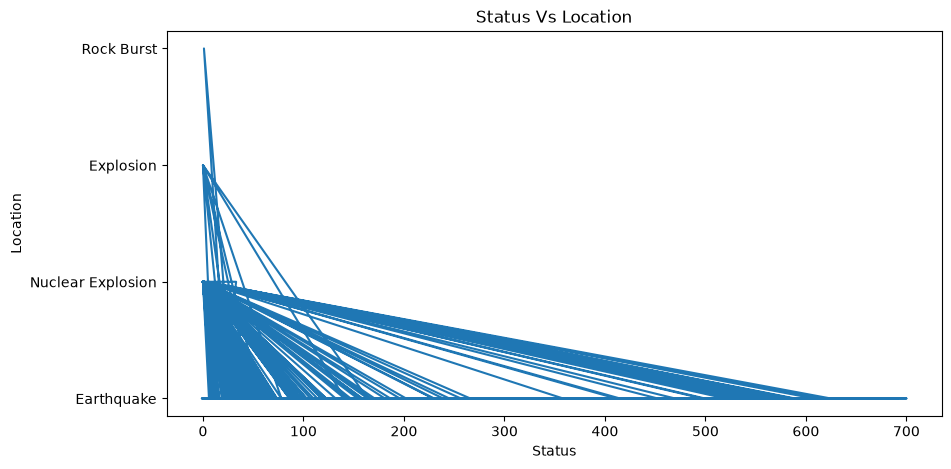

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df["Depth"],df["Type"])
plt.xlabel("Status")
plt.ylabel("Location")
plt.title("Status Vs Location")
plt.show()


In [22]:
df["rino"]=df["Longitude"].rolling(window=3).mean()

In [23]:
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,rino
0,1965-01-02,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic,NaN
1,1965-01-04,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic,NaN
2,1965-01-05,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic,32.998667
3,1965-01-08,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic,-23.392333
4,1965-01-09,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic,-23.700667


In [25]:
value1=df["Longitude"].loc[1]

In [26]:
value2=df["Longitude"].iloc[1]

In [27]:
if value2>value1:
    print("Increasing Trend")
elif value2<value1:
    print("Decreasing Trend")
else:
    print("Stable Trend")

Stable Trend


In [28]:
value1=df["Longitude"].loc[0]

In [29]:
value2=df["Longitude"].iloc[1]


In [30]:
if value2>value1:
    print("Increasing Trend")
elif value2<value1:
    print("Decreasing Trend")
else:
    print("Stable Trend")


Decreasing Trend


In [31]:
value1=df["Longitude"].loc[2]

In [32]:
value2=df["Longitude"].iloc[1]

In [33]:
if value2>value1:
    print("Increasing Trend")
elif value2<value1:
    print("Decreasing Trend")
else:
    print("Stable Trend")


Increasing Trend
